# Data

## Split Videos into Images

We convert raw rollout videos into a dataset of frames:

$$
\text{video} \;\rightarrow\; \{x_1, x_2, \dots, x_T\}, 
\quad x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

Each frame is processed as:

$$
x_t = \text{Resize}_{84 \times 84}\big(\text{Gray}(frame_t)\big)
$$

Frames are stored per episode:

$$
\text{data/frames}/e/\{x_1, x_2, \dots, x_T\}
$$

From this, we construct a dataset of transition pairs:

$$
\mathcal{D} = \{(x_t, x_{t+1})\}
$$

The dataset is then serialized:

$$
\mathcal{D} \;\rightarrow\; \text{data/dataset/dataset.pt}
$$

This removes video decoding overhead and ensures fast, consistent tensor inputs during training.


In [2]:
import cv2
import os

# VIDEO_DIR = "../Donor/videos"
# SAVE_DIR = "data/frames"

# # ustaw cwd tylko jeśli odpalasz jako .py
# if "__file__" in globals():
#     os.chdir(os.path.dirname(os.path.abspath(__file__)))

# os.makedirs(SAVE_DIR, exist_ok=True)

# video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")])

# for vid_idx, video_name in enumerate(video_files):

#     print(f"[PROCESSING] {video_name}")

#     video_path = os.path.join(VIDEO_DIR, video_name)
#     cap = cv2.VideoCapture(video_path)

#     episode_dir = os.path.join(SAVE_DIR, str(vid_idx))
#     os.makedirs(episode_dir, exist_ok=True)

#     frame_id = 0

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#         frame = cv2.resize(frame, (84, 84))

#         save_path = os.path.join(episode_dir, f"{frame_id}.png")
#         cv2.imwrite(save_path, frame)

#         frame_id += 1

#     cap.release()

#     print(f"[DONE] episode {vid_idx} → {frame_id} frames")

# print("ALL DONE")

## Dataset

We construct a dataset of transition pairs from preprocessed frames.

Each episode is a sequence:
$$
\{x_1, x_2, \dots, x_T\}
$$

From this, we build training samples:
$$
(x_t, x_{t+1}), \quad t = 1, \dots, T-1
$$

Each frame is represented as:
$$
x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

The full dataset is a flat collection of tuples:
$$
\mathcal{D} = \{(x_t, x_{t+1})\}
$$

Episode boundaries are not explicitly modeled.  
Temporal consistency is preserved locally through $(x_t, x_{t+1})$, which is sufficient for learning dynamics.

The fundamental learning signal is the transition:
$$
x_t \rightarrow x_{t+1}
$$

The dataset is serialized and stored as:
$$
\mathcal{D} \;\rightarrow\; \text{data/dataset/dataset.pt}
$$

This formulation enables learning action-consistent representations directly from visual state transitions.


## Create

In [3]:
# import os
# import torch
# from torch.utils.data import Dataset
# from PIL import Image
# import torchvision.transforms as T

# # safe cwd
# if "__file__" in globals():
#     os.chdir(os.path.dirname(os.path.abspath(__file__)))


# class VideoDataset(Dataset):
#     def __init__(self, input_dir, output_path=None):
#         self.samples = []
#         self.transform = T.ToTensor()

#         total_pairs = 0

#         for episode in sorted(os.listdir(input_dir)):
#             episode_path = os.path.join(input_dir, episode)

#             if not os.path.isdir(episode_path):
#                 continue

#             frames = sorted(
#                 os.listdir(episode_path),
#                 key=lambda x: int(x.split(".")[0])
#             )

#             num_pairs = len(frames) - 1

#             for i in range(num_pairs):
#                 f1 = os.path.join(episode_path, frames[i])
#                 f2 = os.path.join(episode_path, frames[i+1])

#                 x_t  = Image.open(f1).convert("L")
#                 x_t1 = Image.open(f2).convert("L")

#                 x_t  = self.transform(x_t)
#                 x_t1 = self.transform(x_t1)

#                 self.samples.append((x_t, x_t1))

#             total_pairs += num_pairs
#             print(f"[DATASET] episode {episode} → {num_pairs} pairs")

#         print(f"[DATASET] total pairs: {total_pairs}")

#         # save
#         if output_path is not None:
#             os.makedirs(os.path.dirname(output_path), exist_ok=True)
#             torch.save(self.samples, output_path)
#             print(f"[SAVED] dataset → {output_path}")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         return self.samples[idx]

In [4]:
# dataset = VideoDataset(
#     input_dir="data/frames",
#     output_path="data/dataset/dataset.pt"
# )

## Import

In [5]:
import torch
from torch.utils.data import Dataset

class DownloadVideoDataset(Dataset):
    def __init__(self, dataset_path):
        print(f"[LOADING] {dataset_path}")
        self.samples = torch.load(dataset_path)
        print(f"[LOADED] {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [6]:
dataset = DownloadVideoDataset("data/dataset/dataset.pt")

[LOADING] data/dataset/dataset.pt
[LOADED] 13661 samples


## Explore

In [7]:
from IPython.display import display, Math

display(Math(f"We\\ have\\ {len(dataset)}\\ tuples:\\ (x_t, x_{{t+1}})"))

<IPython.core.display.Math object>

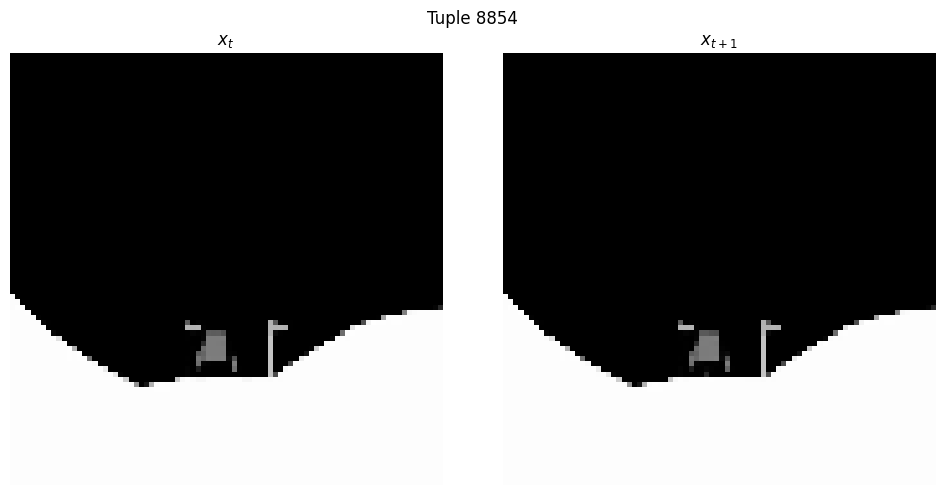

In [91]:
import numpy as np
import matplotlib.pyplot as plt

rand_img = np.random.randint(len(dataset))

x_t0 = dataset[rand_img][0]
x_t1 = dataset[rand_img][1]

fig, axs = plt.subplots(1,2,figsize= (10,5))

axs[0].imshow(x_t0.squeeze(), cmap = 'grey')
axs[0].set_title('$x_t$')
axs[1].imshow(x_t1.squeeze(), cmap = 'grey')
axs[1].set_title('$x_{t+1}$')

for i in range(2):
    axs[i].axis(False)

plt.suptitle(f'Tuple {rand_img}')
plt.tight_layout()
plt.show()

## DataLoader

In [9]:
from torch.utils.data import DataLoader

def get_dataloader(dataset, batch_size=64, shuffle=True, num_workers=0):
    print(f"[DATALOADER] batch_size={batch_size}")

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,  # w notebooku = 0
        pin_memory=True
    )

In [10]:
dataloader = get_dataloader(dataset)

for x_t, x_t1 in dataloader:
    print(x_t.shape)
    break

[DATALOADER] batch_size=64
torch.Size([64, 1, 84, 84])


/Users/adriankazi/miniconda3/envs/dl-video-learning/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


# Model 0

## Intro

Model 0 is to see if we can successfully predict next frame. Model 0 includes:

* state representation - $x_t \text{ frame} \rightarrow z_t \text{ latent}$
* dynamics             - $z_t \text{ latent }_t \rightarrow z_{t+1} \text{ latent }_{t+1}$
* reconstruction       - $z_t \text{ latent} \rightarrow x_t \text{ frame} $  

To put it simply Model 0 learns how world works from frames.

Model Input: $(x_t, x_{t+1})$

Model Output: 

$$z_{t+1}        = f(x_{t+1})       \text{ (true latent)}$$
$$z_{t+1}^{hat}  = h(z_t, a_t)       \text{ (predicted latent)}$$
$$x_{t+1}^{hat}  = d(z_{t+1}^{hat})  \text{ (predicted frame)} $$
$$x_{t+1}^{recon}= d(z_{t+1})        \text{ (reconstruction)} $$

## Math

$x_t$ is a single video frame (image at time t)

$$
z_t = f_{\theta}(x_t)
$$

$f_{\theta}$ = CNN encoder (neural network with parameters $\theta$)  
*Input:* image $x_t$  
*Output:* latent vector $z_t$ (compressed numeric representation of the frame)

---

$$
z_{t+1} = f_{\theta}(x_{t+1})
$$

Same CNN encoder  
*Input:* next image $x_{t+1}$  
*Output:* true next latent representation $z_{t+1}$

---

$$
\hat{a}_t = g_{\phi}(z_t, z_{t+1})
$$

$g_{\phi}$ = Action Inference Network (MLP with parameters $\phi$)  
*Input:* current latent $z_t$ and next latent $z_{t+1}$  
*Output:* inferred action $\hat{a}_t$ that best explains transition

---

$$
\hat{z}_{t+1} = h_{\psi}(z_t, \hat{a}_t)
$$

$h_{\psi}$ = Dynamics model (MLP or RNN with parameters $\psi$)  
*Input:* current latent $z_t$ and inferred action $\hat{a}_t$  
*Output:* predicted next latent $\hat{z}_{t+1}$

---

$$
\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})
$$

$d_{\omega}$ = Decoder network (neural network with parameters $\omega$)  
*Input:* predicted latent $\hat{z}_{t+1}$  
*Output:* predicted next image $\hat{x}_{t+1}$

---

$$
L_{pixel}^{dyn} = \| x_{t+1} - \hat{x}_{t+1} \|^2
$$

Pixel reconstruction loss from dynamics  
*Input:* true frame $x_{t+1}$ and predicted frame $\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})$  
*Output:* scalar reconstruction error

---

$$
L_{pixel}^{ae} = \| x_{t+1} - \tilde{x}_{t+1} \|^2
$$

Autoencoder reconstruction loss (MSE)  
*Input:* true frame $x_{t+1}$ and reconstructed frame $\tilde{x}_{t+1} = d_{\omega}(z_{t+1})$  
*Output:* scalar reconstruction error

---

$$
L_{latent} = \| z_{t+1} - \hat{z}_{t+1} \|^2
$$

Latent consistency loss (MSE)  
*Input:* true latent $z_{t+1}$ and predicted latent $\hat{z}_{t+1}$  
*Output:* scalar latent error

---

$$
L = L_{pixel}^{dyn} + \alpha L_{latent} + \beta L_{pixel}^{ae}
$$

Total training loss minimized during learning

## Code

In [102]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WorldModel(nn.Module):
    def __init__(self, z_dim=128, a_dim=2):
        super().__init__()

        # f_theta (encoder)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*8*8, z_dim)
        )

        # g_phi (inverse dynamics)
        self.inverse = nn.Sequential(
            nn.Linear(z_dim*2, 256),
            nn.ReLU(),
            nn.Linear(256, a_dim)
        )

        # h_psi (forward dynamics)
        self.dynamics = nn.Sequential(
            nn.Linear(z_dim + a_dim, 256),
            nn.ReLU(),
            nn.Linear(256, z_dim)
        )

        # d_omega (decoder)
        self.decoder_fc = nn.Linear(z_dim, 128*8*8)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 10, stride=2)
        )

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 128, 8, 8)
        x = self.decoder_conv(x)

        return x

    def forward(self, x_t, x_t1):
        # encode
        z_t  = self.encoder(x_t)
        z_t1 = self.encoder(x_t1)

        # inverse dynamics
        a_t = self.inverse(torch.cat([z_t, z_t1], dim=1))

        # forward dynamics
        z_t1_hat = self.dynamics(torch.cat([z_t, a_t], dim=1))

        # decode
        x_t1_hat   = self.decode(z_t1_hat)  # from dynamics
        x_t1_recon = self.decode(z_t1)      # autoencoder

        # z_t1        - true latent of x_t1 (encoder output)
        # z_t1_hat    - predicted latent from dynamics model
        # x_t1_hat    - predicted frame from z_t1_hat (future prediction)
        # x_t1_recon  - reconstructed frame from z_t1 (autoencoder path)

        return z_t1, z_t1_hat, x_t1_hat, x_t1_recon


def loss_fn(x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat, alpha=1.0, beta=1.0):
    L_pixel_dyn = F.mse_loss(x_t1_hat, x_t1)
    L_pixel_ae  = F.mse_loss(x_t1_recon, x_t1)
    L_latent    = F.mse_loss(z_t1_hat, z_t1)

    L = L_pixel_dyn + alpha * L_latent + beta * L_pixel_ae

    return L, L_pixel_dyn, L_latent, L_pixel_ae

## Debug Spin

In [113]:
model = WorldModel()
model.train()

# 1 batch
x_t0, x_t1 = next(iter(dataloader))

# forward
z_t1, z_t1_hat, x_t1_hat, x_t1_recon = model(x_t0, x_t1)

# loss
L, L_dyn, L_latent, L_ae = loss_fn(x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat)

print("SHAPES:")
print("x_t0:      ",x_t0.shape)
print("x_t1:      ", x_t1.shape)
print("x_t1_hat:  ",x_t1_hat.shape)
print("x_t1_recon:",x_t1_recon.shape)

print('\nLOSSES:')
print(f"Total:     {L.item():.4f}")
print(f"Pixel dyn: {L_dyn.item():.4f}")
print(f"Latent:    {L_latent.item():.4f}")
print(f"Pixel AE:  {L_ae.item():.4f}")


SHAPES:
x_t0:       torch.Size([64, 1, 84, 84])
x_t1:       torch.Size([64, 1, 84, 84])
x_t1_hat:   torch.Size([64, 1, 84, 84])
x_t1_recon: torch.Size([64, 1, 84, 84])

LOSSES:
Total:     0.5735
Pixel dyn: 0.2856
Latent:    0.0022
Pixel AE:  0.2856


## Loss Test Spin

In [ ]:
import torch

model = WorldModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()

num_epochs = 3
num_steps = len(dataloader)

loss_total  = torch.zeros(num_epochs, num_steps)
loss_dyn    = torch.zeros(num_epochs, num_steps)
loss_latent = torch.zeros(num_epochs, num_steps)
loss_ae     = torch.zeros(num_epochs, num_steps)

for epoch in range(num_epochs):

    for i, (x_t, x_t1) in enumerate(dataloader):

        optimizer.zero_grad()

        z_t1, z_t1_hat, x_t1_hat, x_t1_recon = model(x_t, x_t1)

        L, L_dyn, L_latent, L_ae = loss_fn(
            x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat
        )

        L.backward()
        optimizer.step()

        loss_total[epoch, i]  = L.detach()
        loss_dyn[epoch, i]    = L_dyn.detach()
        loss_latent[epoch, i] = L_latent.detach()
        loss_ae[epoch, i]     = L_ae.detach()

        if i % 50 == 0:
            print(f"Epoch {epoch} | Step {i:>4} | Loss {L.item():.4f}")

Epoch 0 | Step 0 | Loss 0.5308
Epoch 0 | Step 50 | Loss 0.0572
Epoch 0 | Step 100 | Loss 0.0289
Epoch 0 | Step 150 | Loss 0.0158
Epoch 0 | Step 200 | Loss 0.0114
Epoch 1 | Step 0 | Loss 0.0106
Epoch 1 | Step 50 | Loss 0.0083
Epoch 1 | Step 100 | Loss 0.0075
Epoch 1 | Step 150 | Loss 0.0064
Epoch 1 | Step 200 | Loss 0.0053
Epoch 2 | Step 0 | Loss 0.0049
Epoch 2 | Step 50 | Loss 0.0045
Epoch 2 | Step 100 | Loss 0.0046
Epoch 2 | Step 150 | Loss 0.0036
Epoch 2 | Step 200 | Loss 0.0034


## Loss Plots

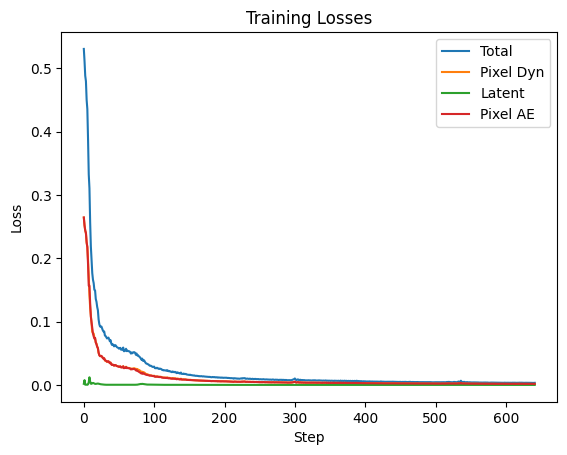

In [124]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_total.view(-1),  label="Total")
plt.plot(loss_dyn.view(-1),    label="Pixel Dyn")
plt.plot(loss_latent.view(-1), label="Latent")
plt.plot(loss_ae.view(-1),     label="Pixel AE")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.show()

# Model 1

# Lunar Lander

In [ ]:
import numpy as np

class RandomPolicy:
    def __init__(self, action_dim=2):
        self.action_dim = action_dim

    def __call__(self, state):
        return np.random.uniform(-1, 1, size=(self.action_dim,)).astype(np.float32)
        # return model(state)

In [ ]:
import gymnasium as gym
import numpy as np

class LunarLanderRunner:
    def __init__(self, policy):
        self.env = gym.make("LunarLanderContinuous-v3", render_mode="human")
        self.policy = policy

    def run(self, episodes=3):

        for ep in range(episodes):

            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:

                action = self.policy(state)

                action = np.array(action, dtype=np.float32).reshape(-1)

                state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                total_reward += reward

            print(f"Episode {ep} | Reward: {total_reward:.2f}")

        self.env.close()

In [149]:
policy = RandomPolicy()
runner = LunarLanderRunner(policy)

runner.run(episodes=3)

Episode 0 | Reward: -318.33
Episode 1 | Reward: -22.25
Episode 2 | Reward: -250.70


In [ ]:
state = np.array([
    0.0,   # x position
    1.0,   # y position (wysoko nad ziemią)
    0.0,   # velocity x
    0.0,   # velocity y
    0.0,   # angle
    0.0,   # angular velocity
    0.0,   # left leg contact
    0.0    # right leg contact
], dtype=np.float32)
policy = RandomPolicy()
policy(state)

array([0.873906 , 0.5964875], dtype=float32)